In [1]:
#!pip install opencv-python
from data import load_mri_dataframe, get_dataloaders

In [2]:
df = load_mri_dataframe()

train_loader, val_loader = get_dataloaders(df, omit_empty_masks=True)

[Data] Train images: 1093 ; Val images: 280


In [3]:
import torch
import torch.nn as nn

In [4]:
class BaselineUNet(nn.Module):
    def __init__(self):
        super().__init__()
        num_classes = 1
        # Encoder
        self.enc1 = nn.Sequential(nn.Conv2d(3, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)  # 128x128

        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)  # 64x64

        # Bottleneck
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())

        # Decoder
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)  # 64x64
        self.dec2 = nn.Sequential(nn.Conv2d(64, 32, 3, padding=1), nn.ReLU())

        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)  # 128x128
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU())

        # Final
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        return self.final(d1)


In [5]:
model = BaselineUNet()

device = torch.device('cuda')

Epoch 200/200: 100%|██████████| 137/137 [00:13<00:00, 10.23it/s]


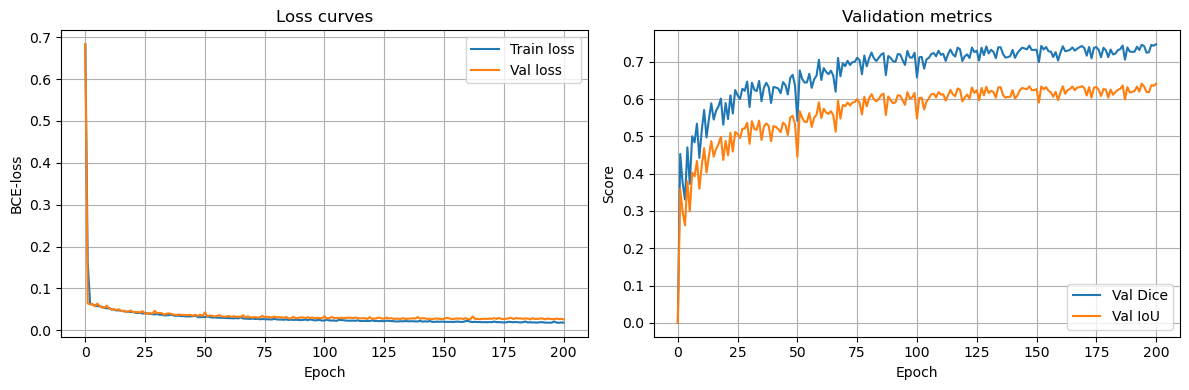

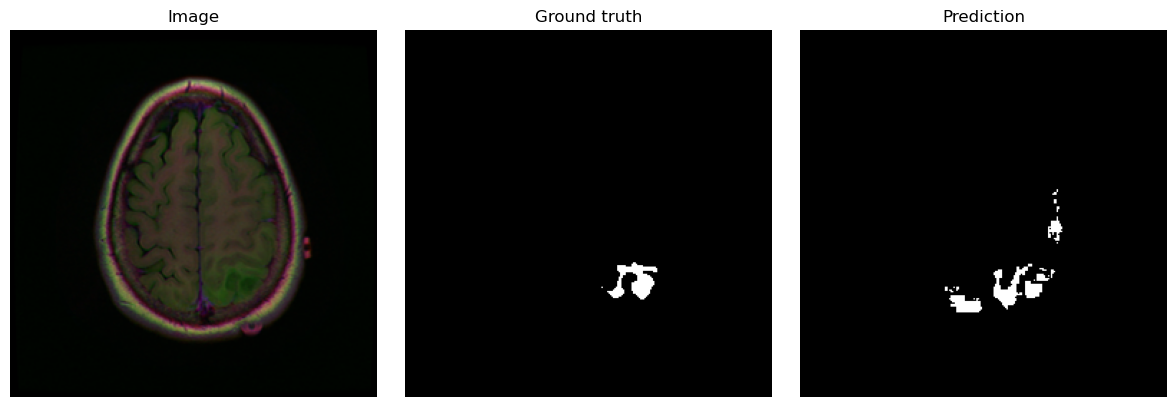

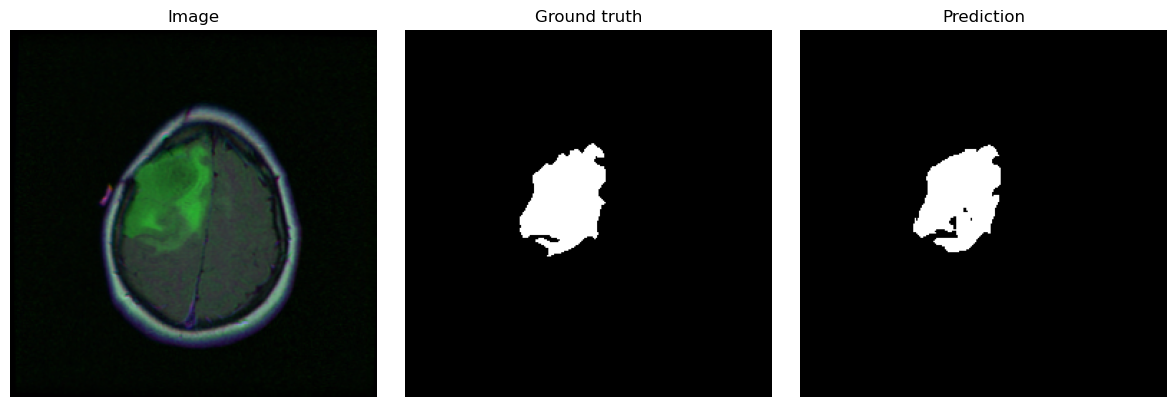

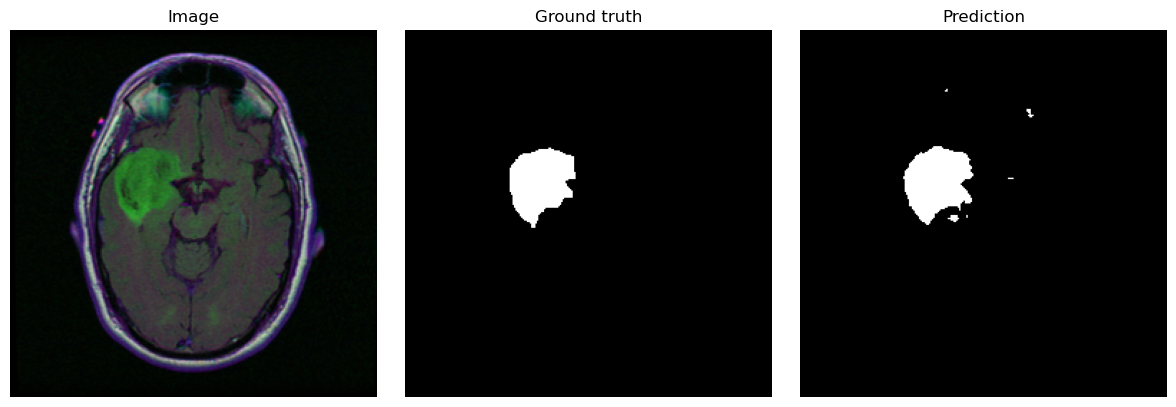

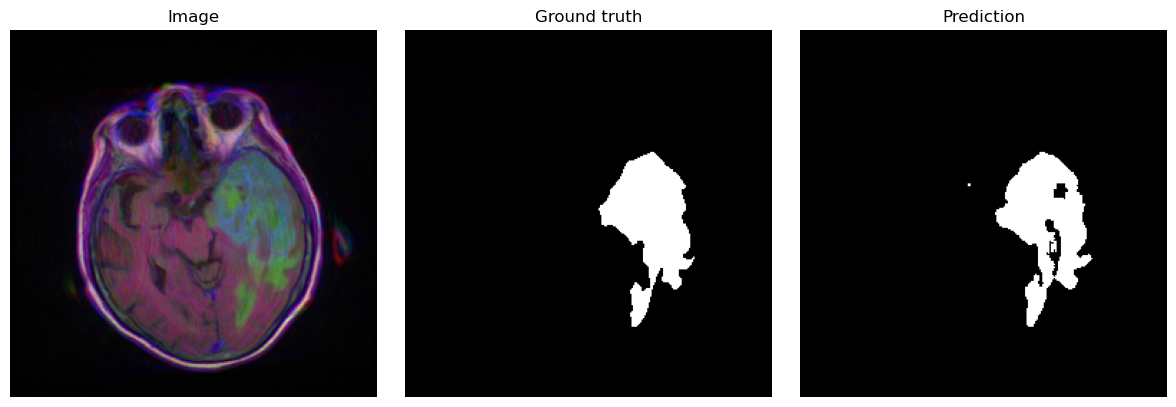

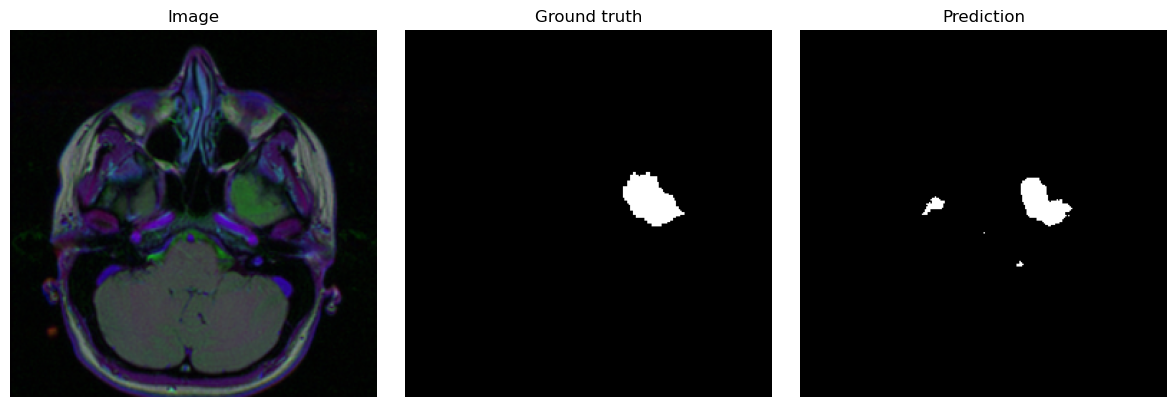

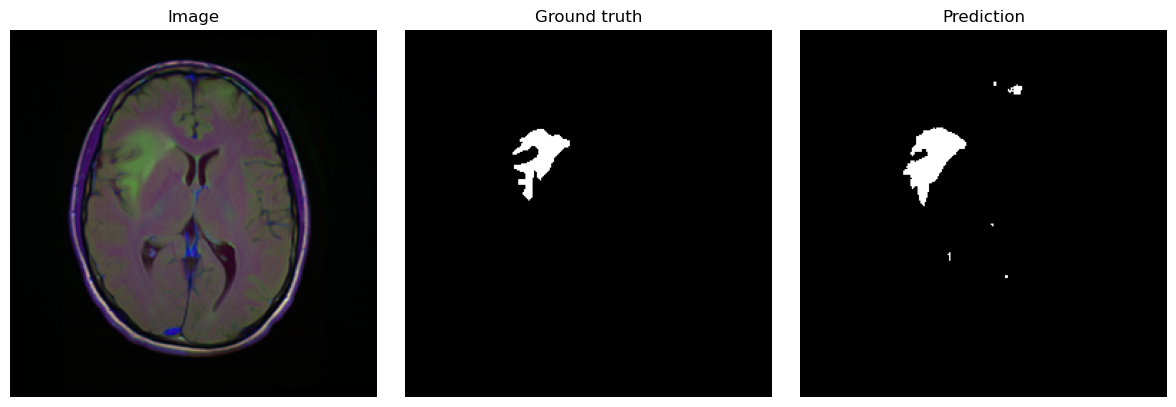

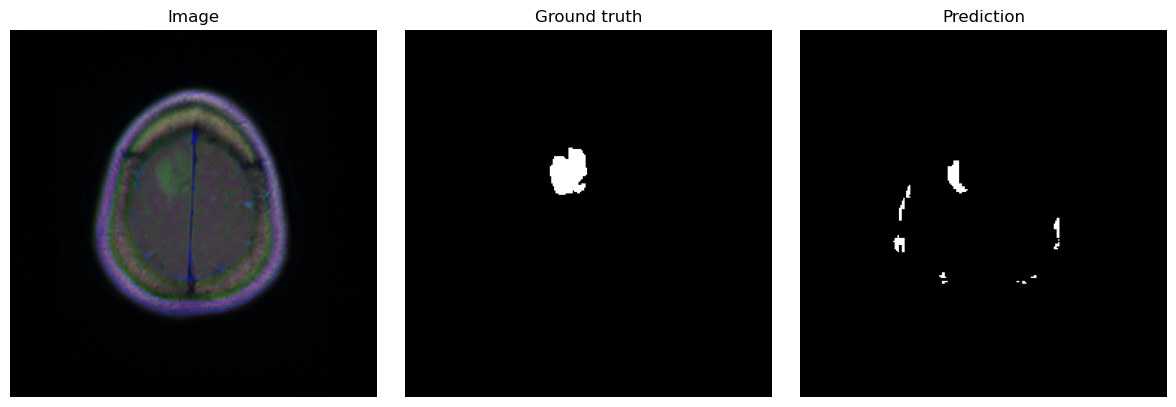

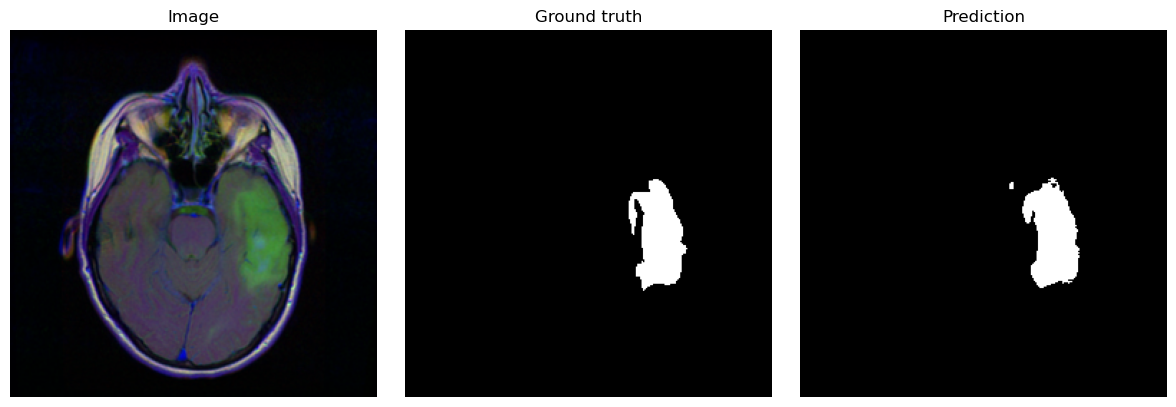

Final Val Dice: 0.7471
Final Val IoU : 0.6414


In [6]:
from train_bce_dice_loss import train_bce_dice_loss, bce_dice_loss, dice_loss, bce_loss, focal_loss, tversky_loss
from eval import evaluate

model.to(device)
trained_model_bce, results_bce = train_bce_dice_loss(bce_loss, model, train_loader, val_loader, device)
evaluate(results_bce)


Epoch 200/200: 100%|██████████| 137/137 [00:12<00:00, 10.61it/s]


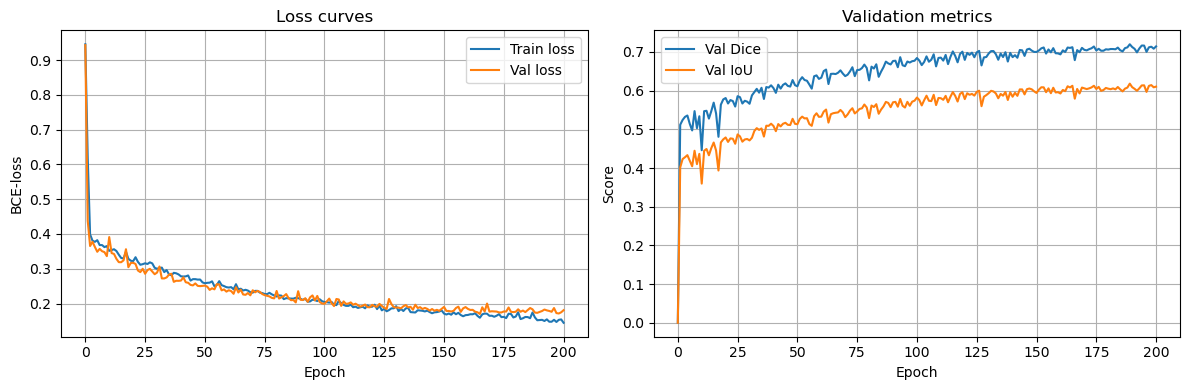

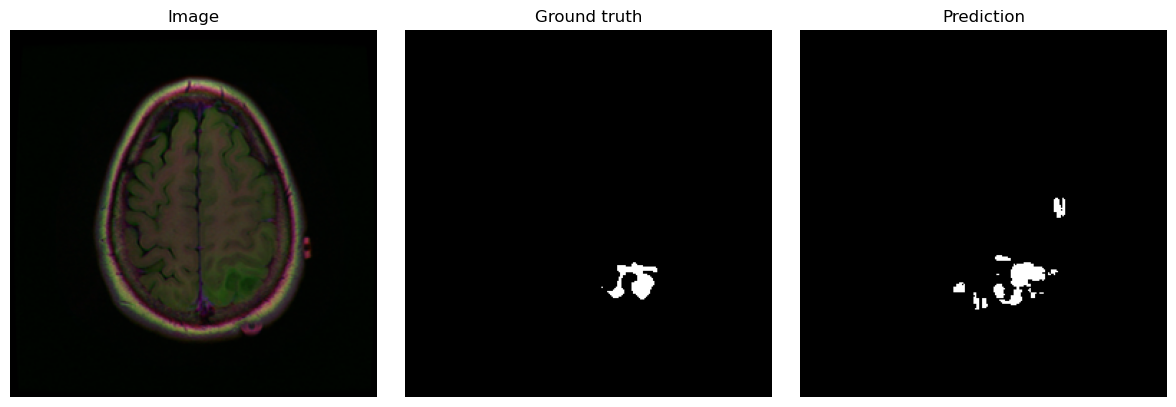

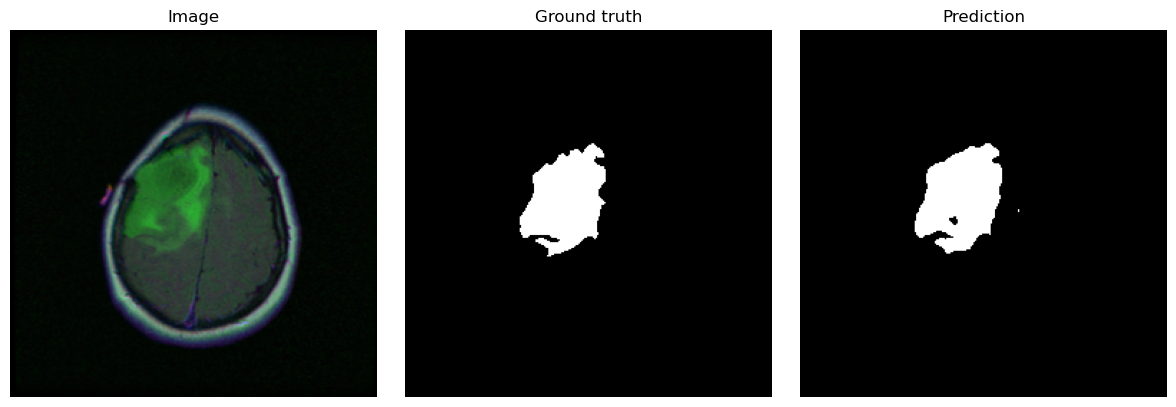

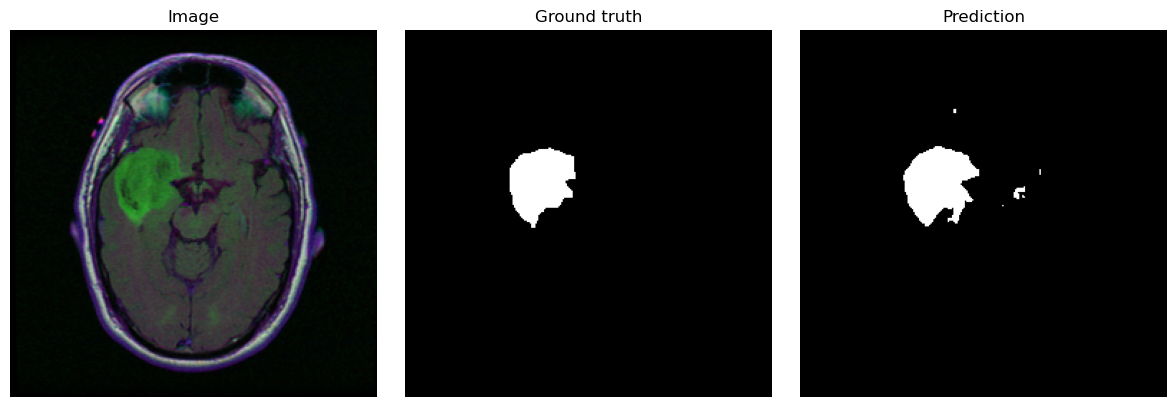

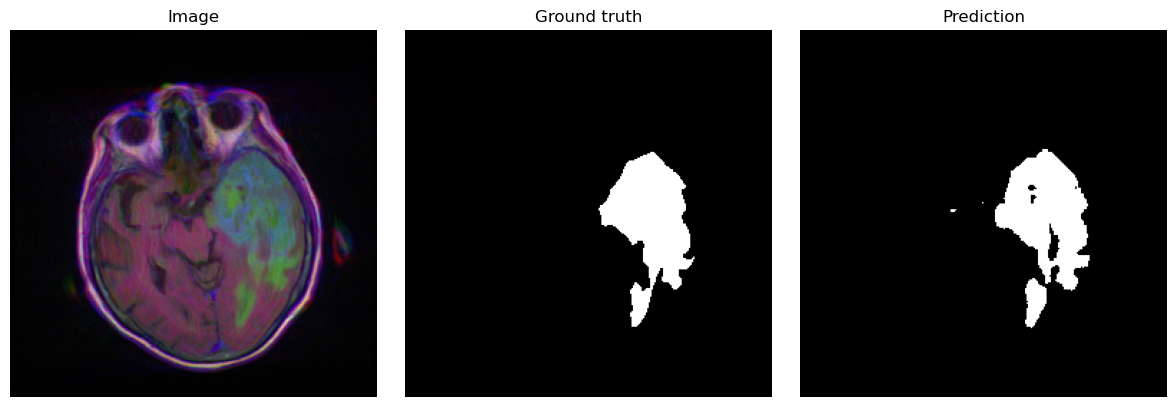

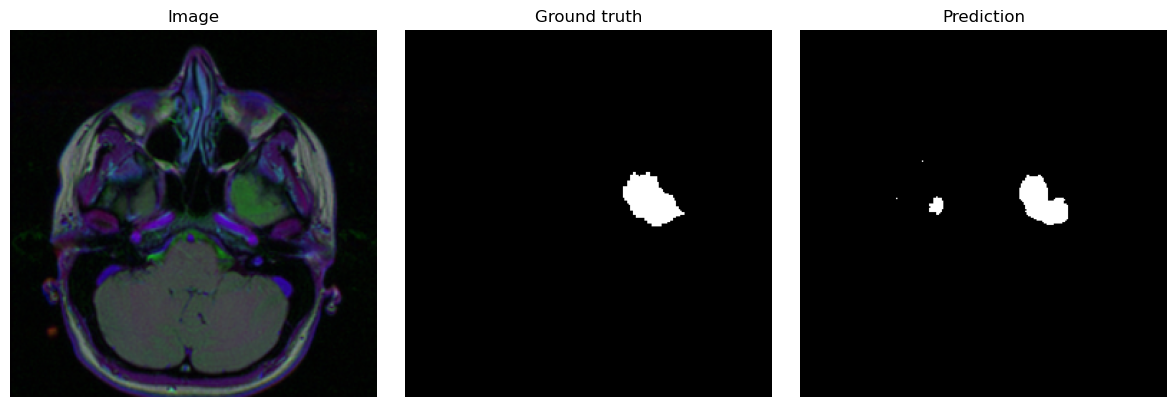

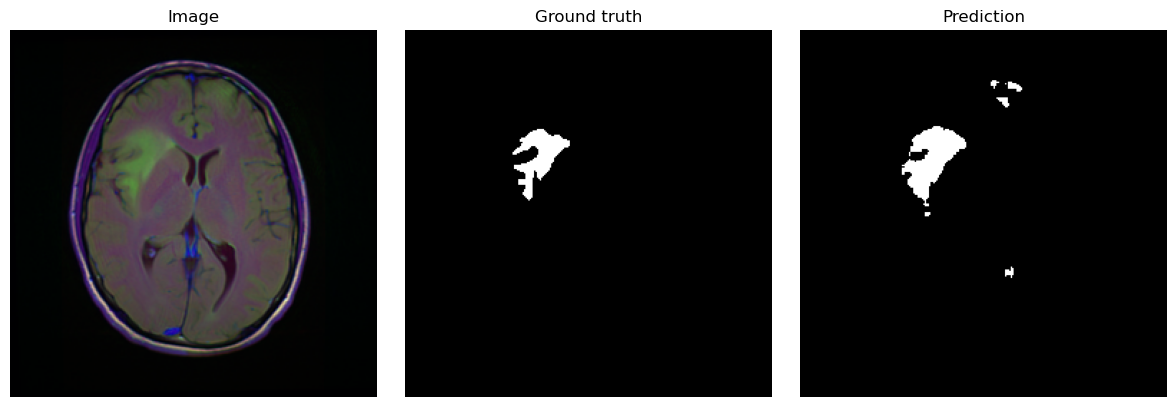

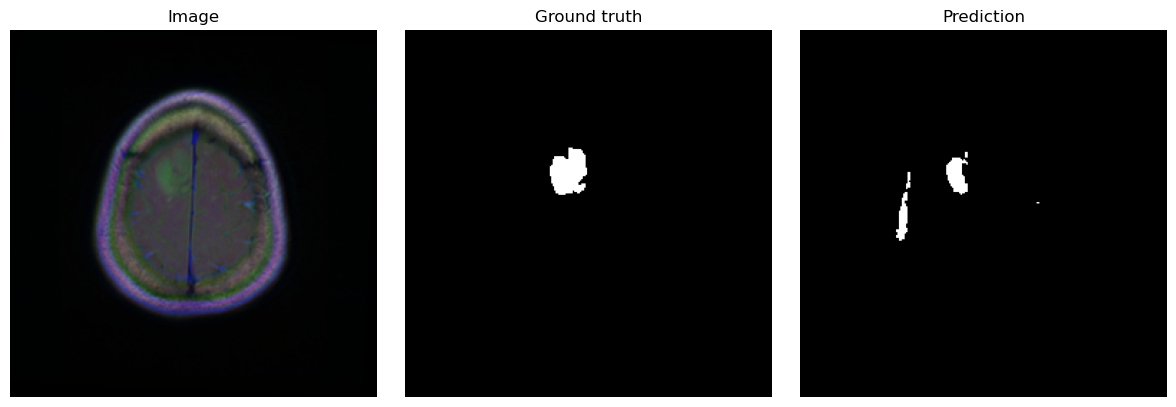

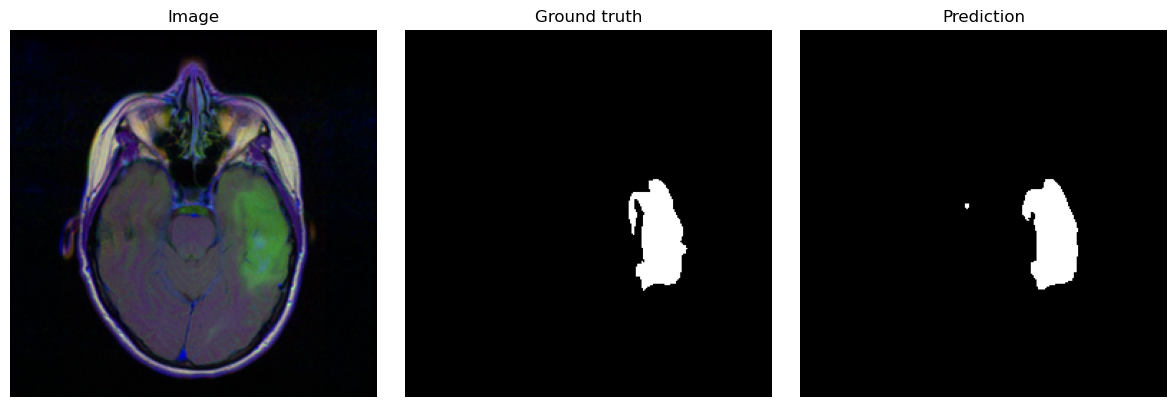

Final Val Dice: 0.7143
Final Val IoU : 0.6103


In [7]:
model = BaselineUNet()
device = torch.device('cuda')
model.to(device)
trained_model_dice, results_dice = train_bce_dice_loss(dice_loss, model, train_loader, val_loader, device)
evaluate(results_dice)

Epoch 200/200: 100%|██████████| 137/137 [00:13<00:00, 10.24it/s]


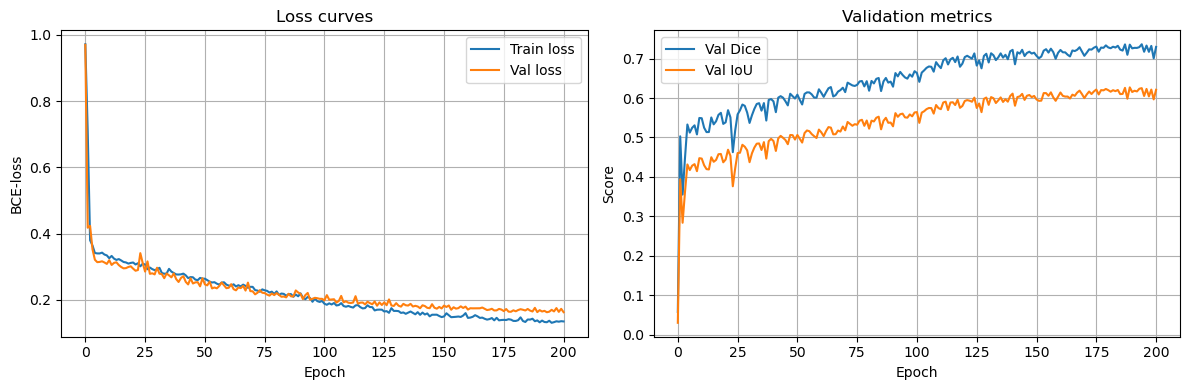

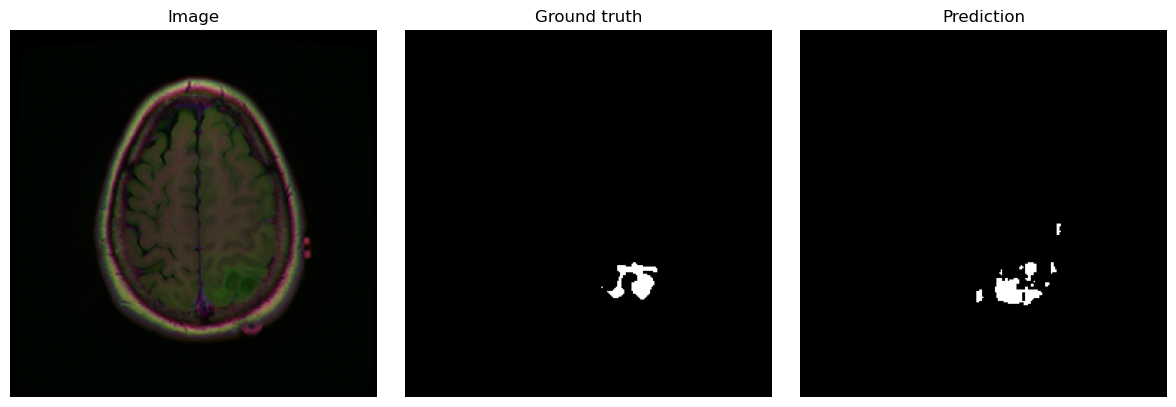

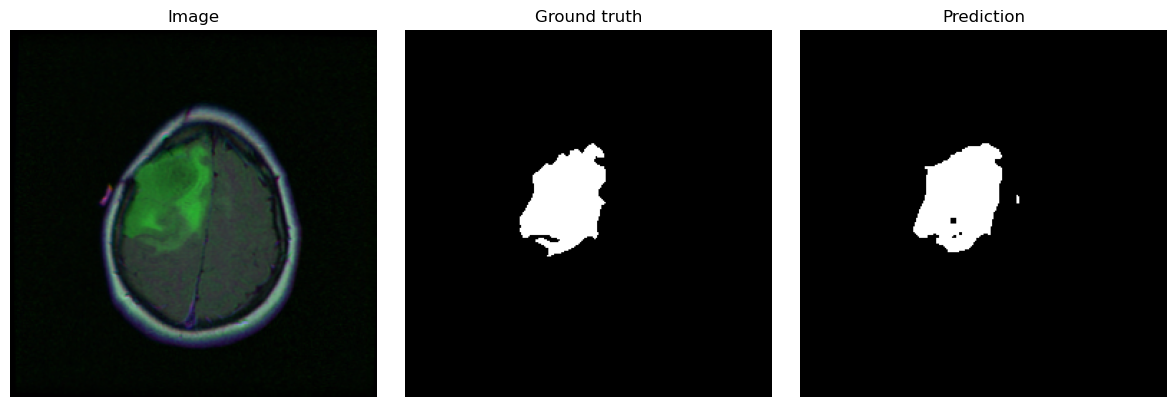

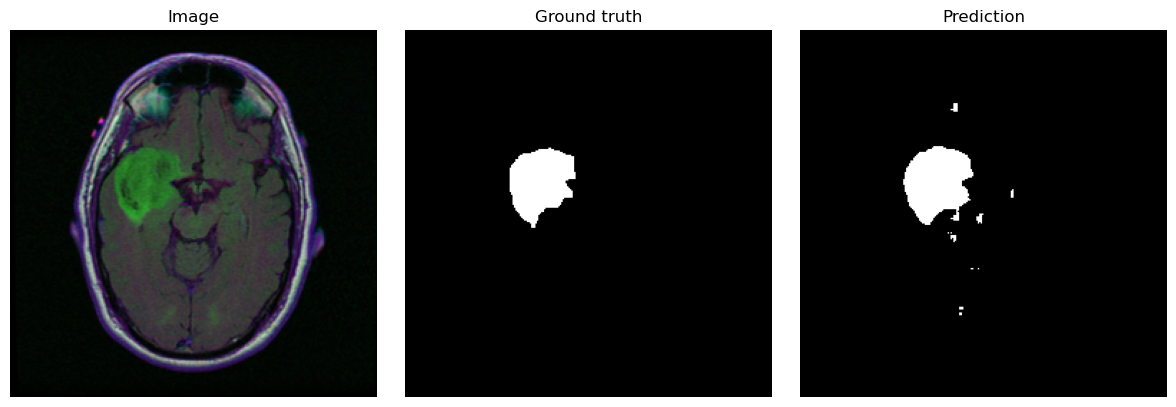

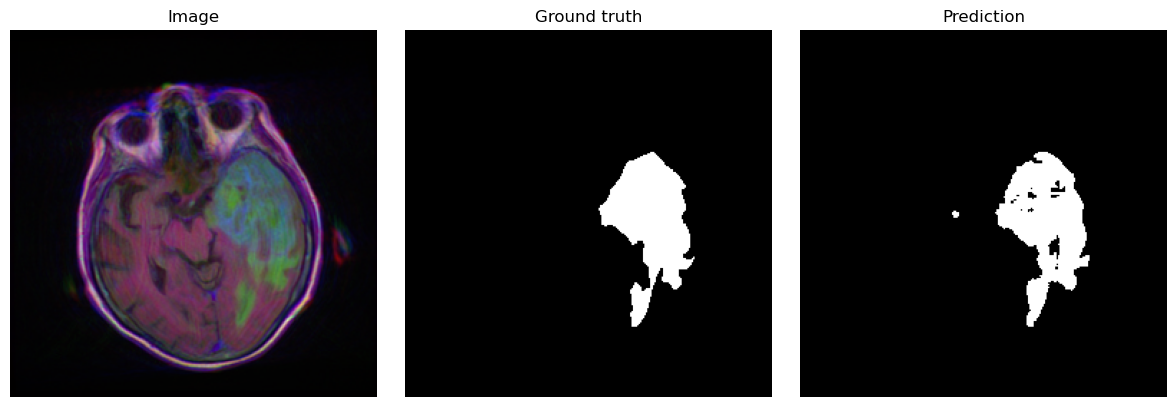

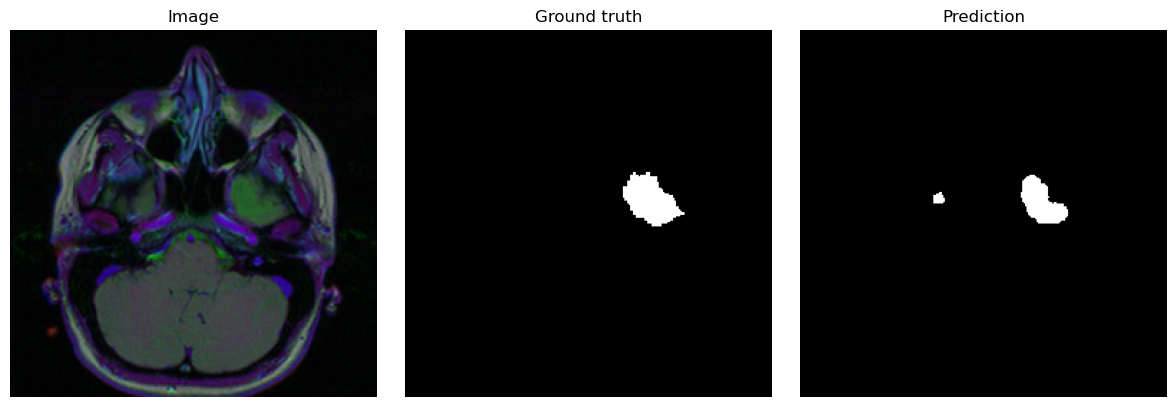

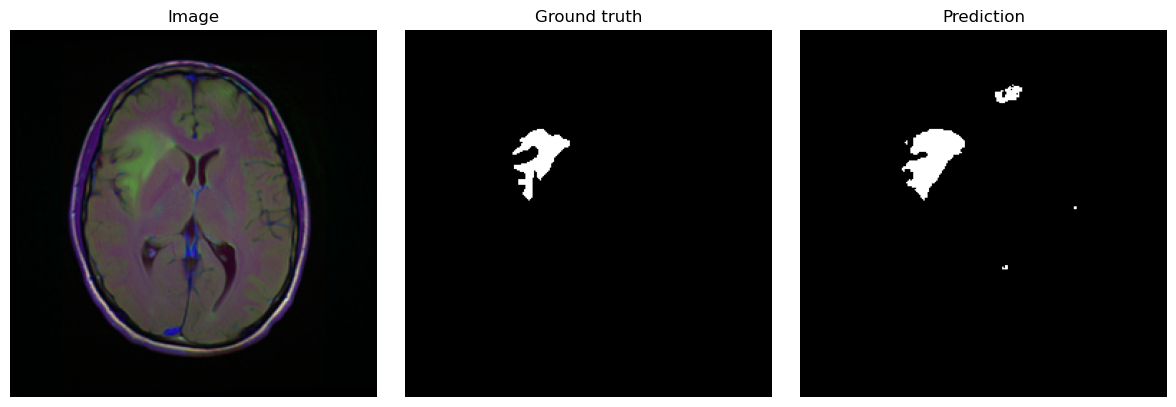

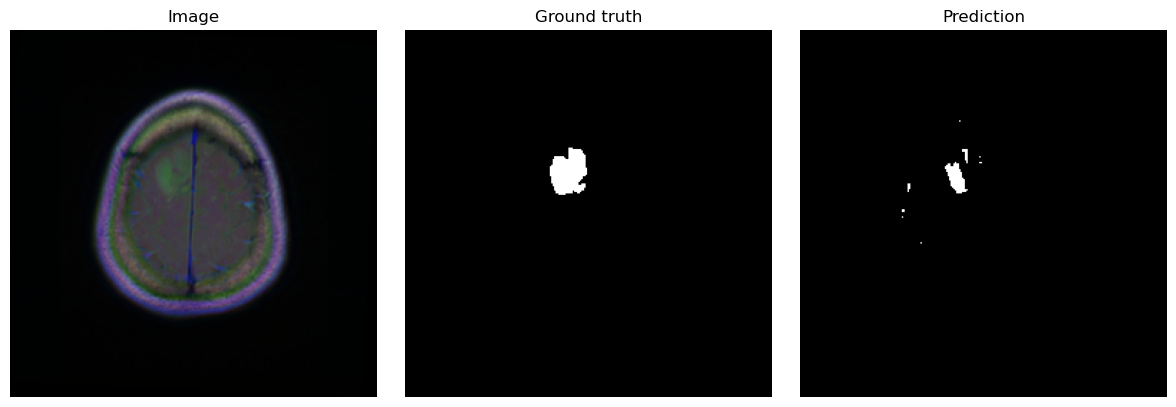

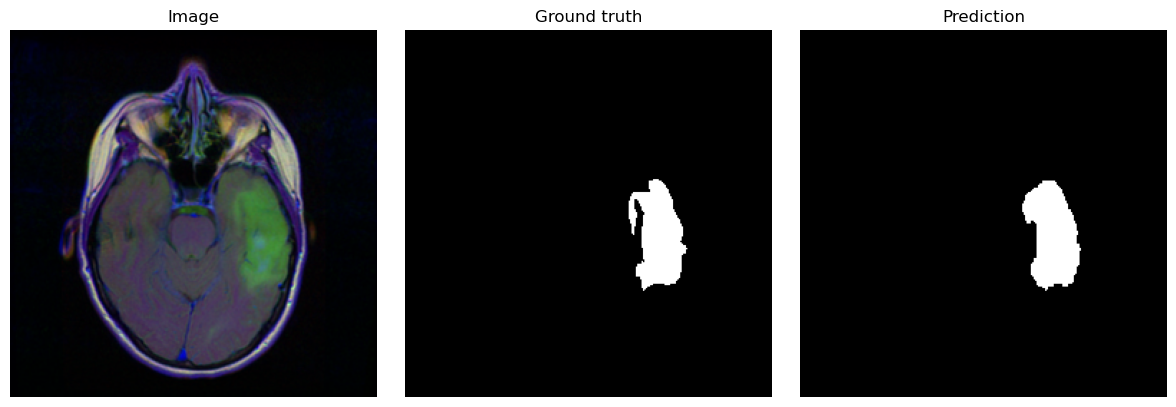

Final Val Dice: 0.7294
Final Val IoU : 0.6208


In [8]:
model = BaselineUNet()
device = torch.device('cuda')
model.to(device)
trained_model_bce_dice, results_bce_dice = train_bce_dice_loss(bce_dice_loss, model, train_loader, val_loader, device)
evaluate(results_bce_dice)

Epoch 200/200: 100%|██████████| 137/137 [00:13<00:00, 10.42it/s]


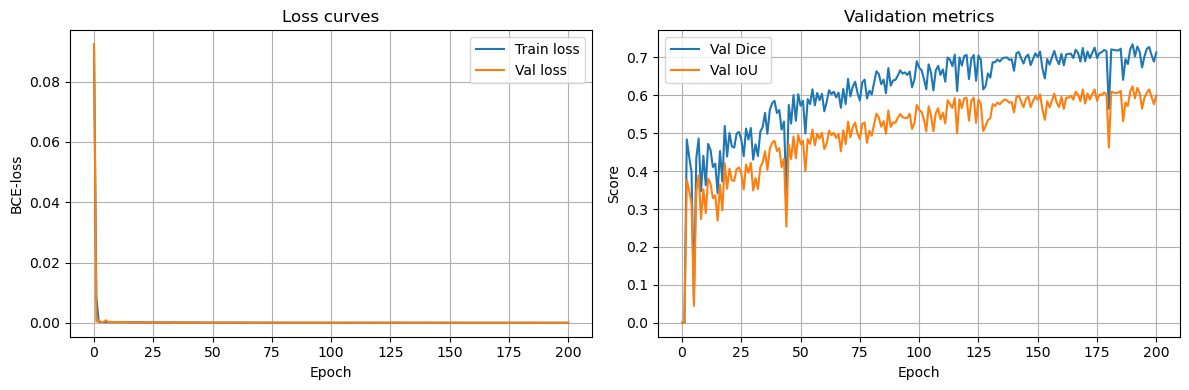

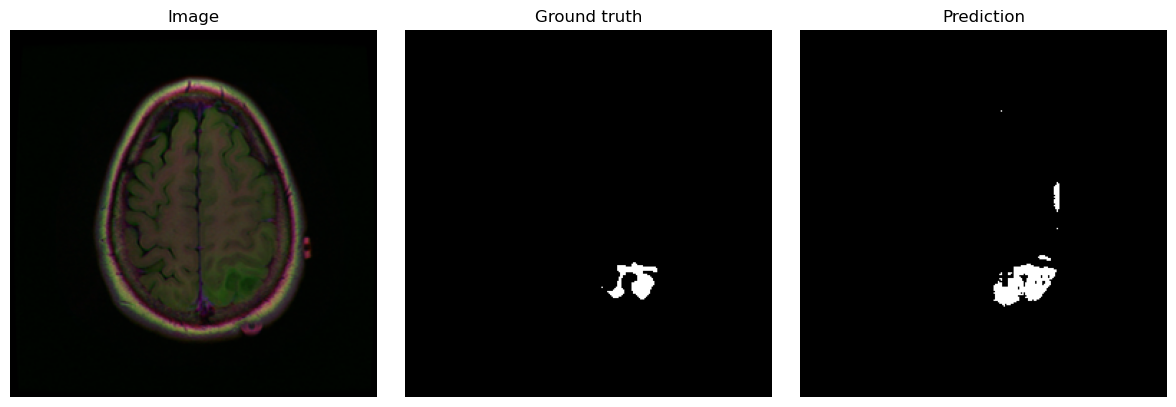

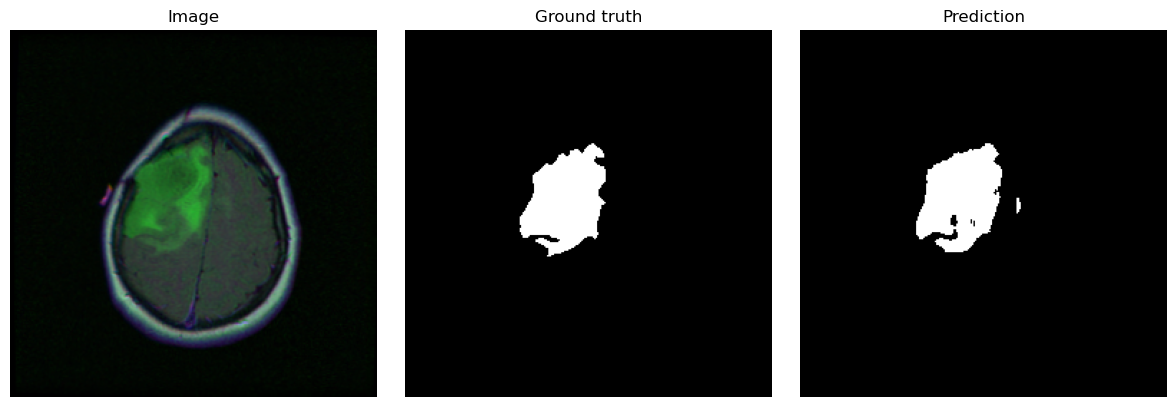

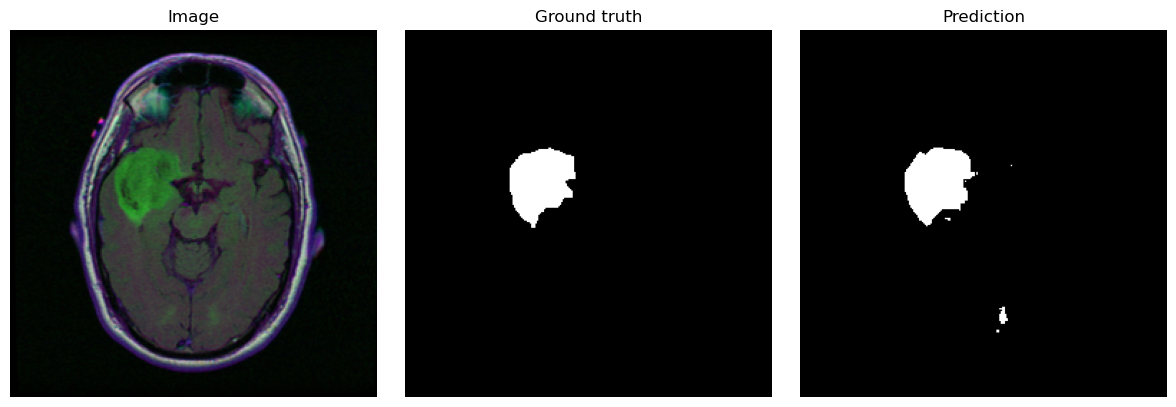

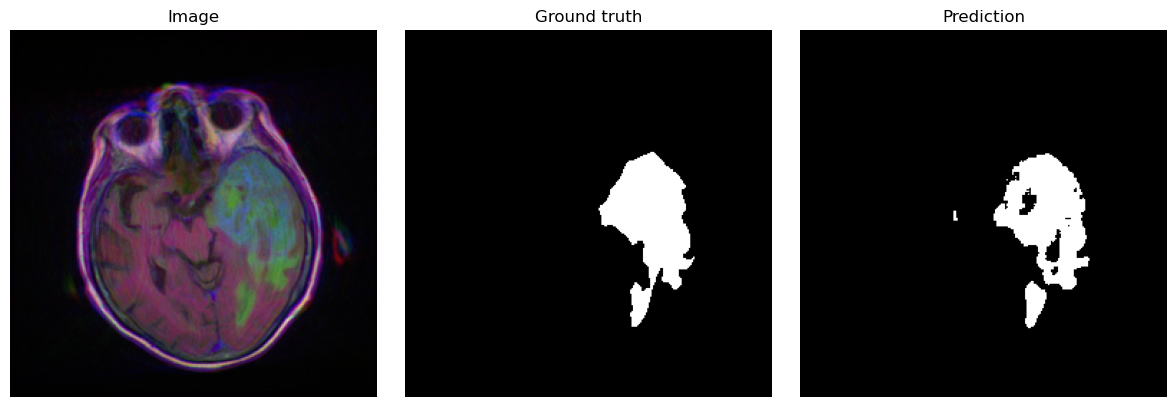

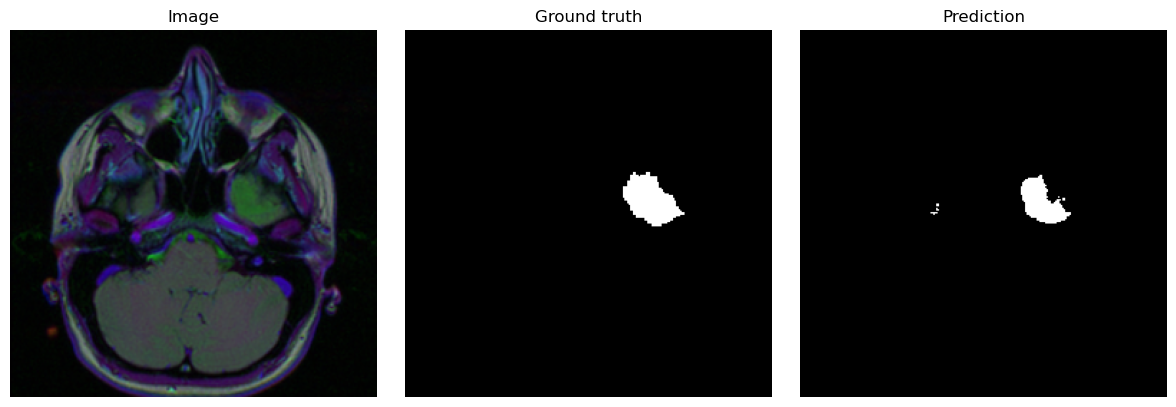

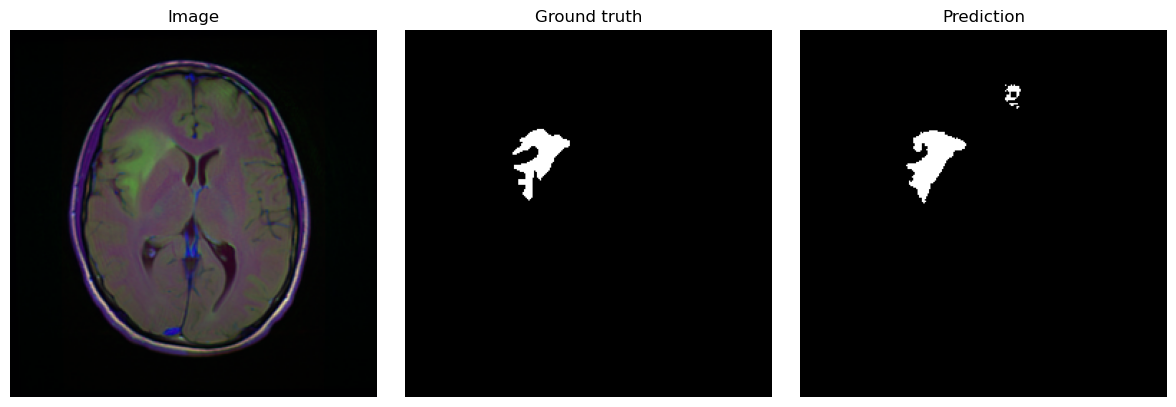

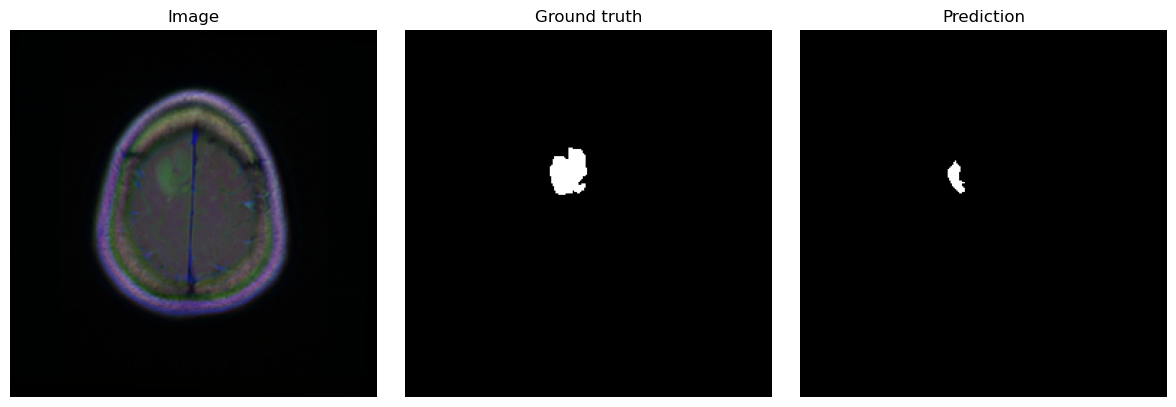

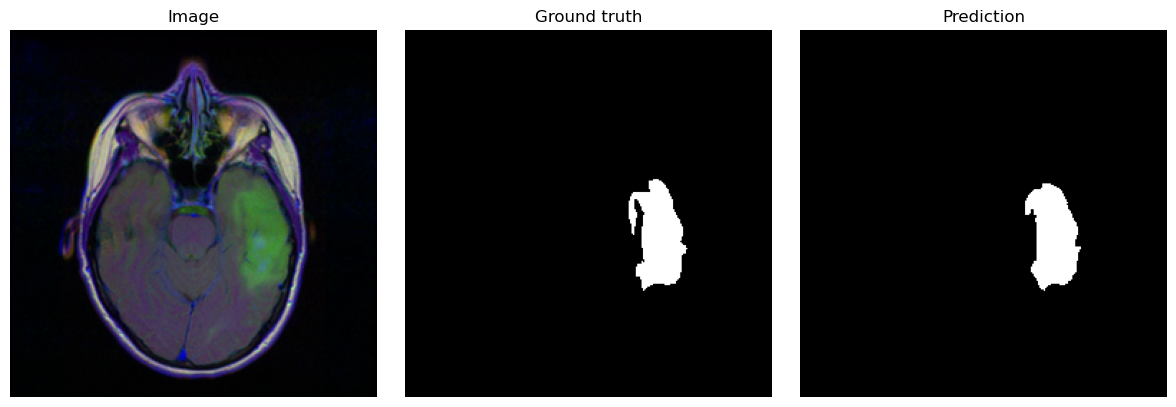

Final Val Dice: 0.7125
Final Val IoU : 0.5996


In [9]:
model = BaselineUNet()
device = torch.device('cuda')
model.to(device)
trained_model_focal, results_focal = train_bce_dice_loss(focal_loss, model, train_loader, val_loader, device)
evaluate(results_focal)

Epoch 200/200: 100%|██████████| 137/137 [00:12<00:00, 10.59it/s]


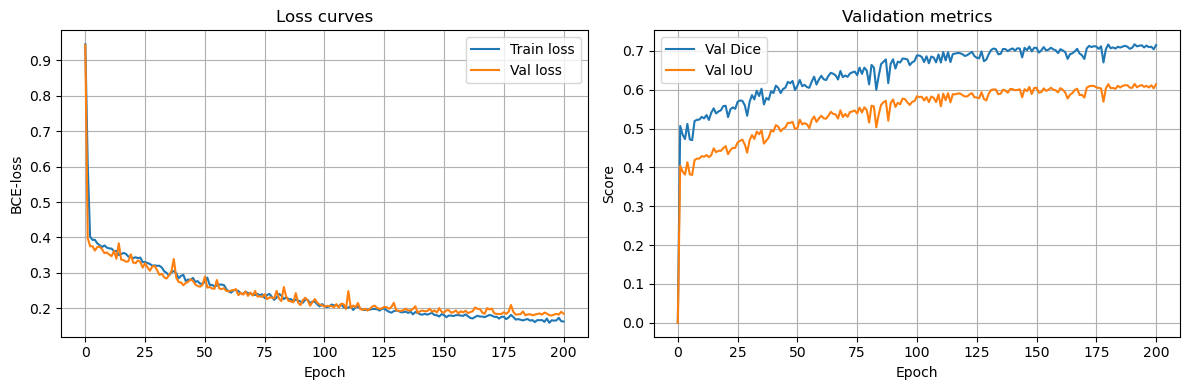

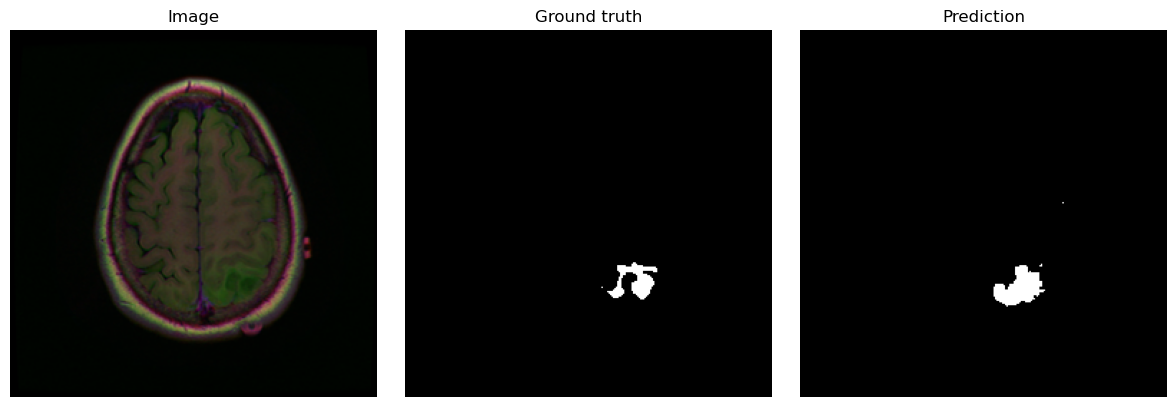

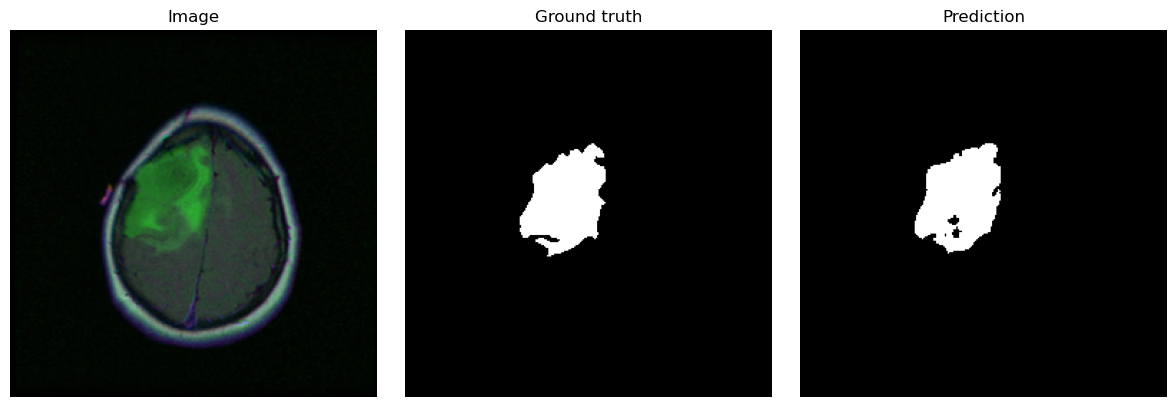

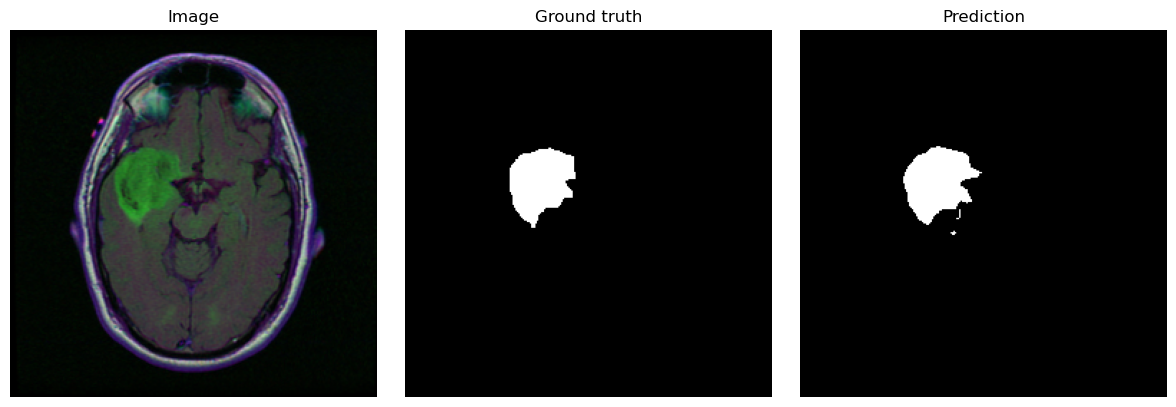

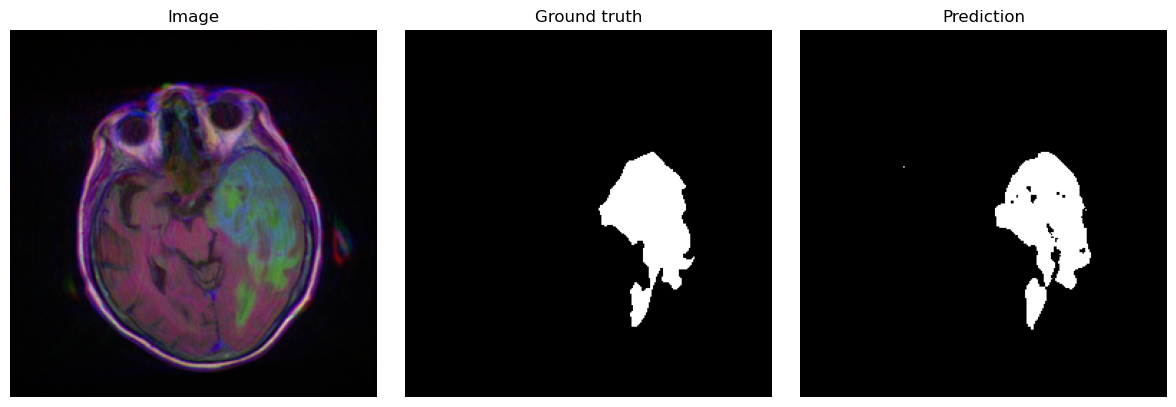

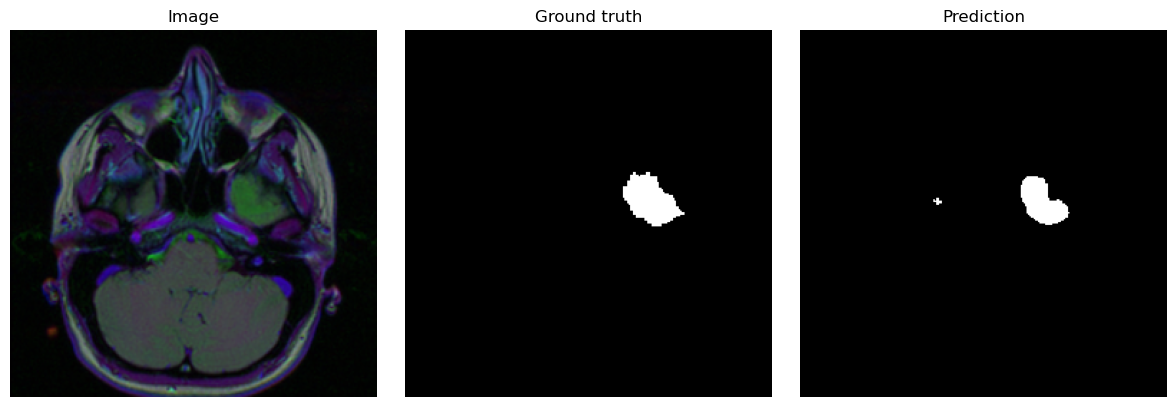

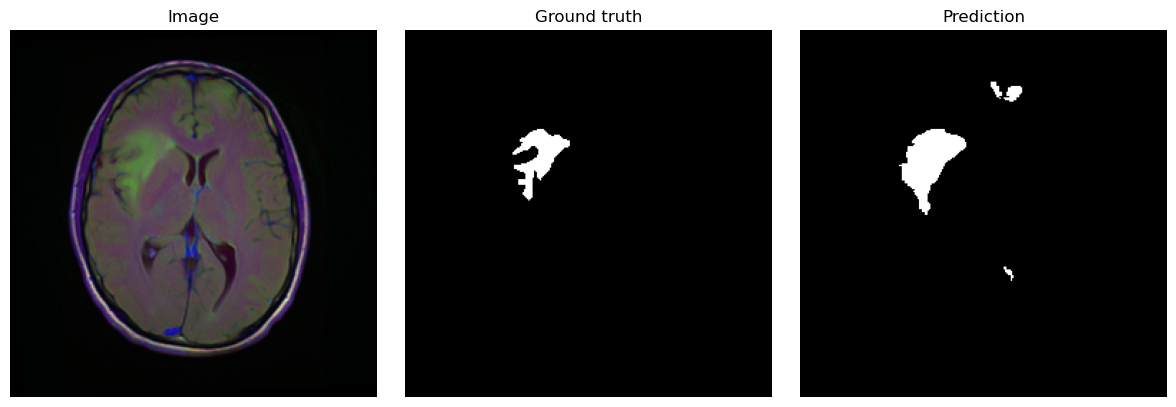

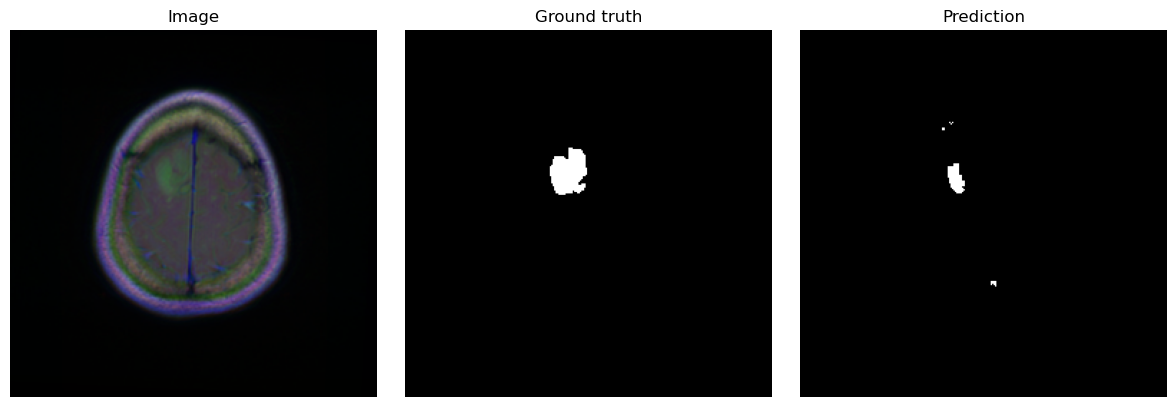

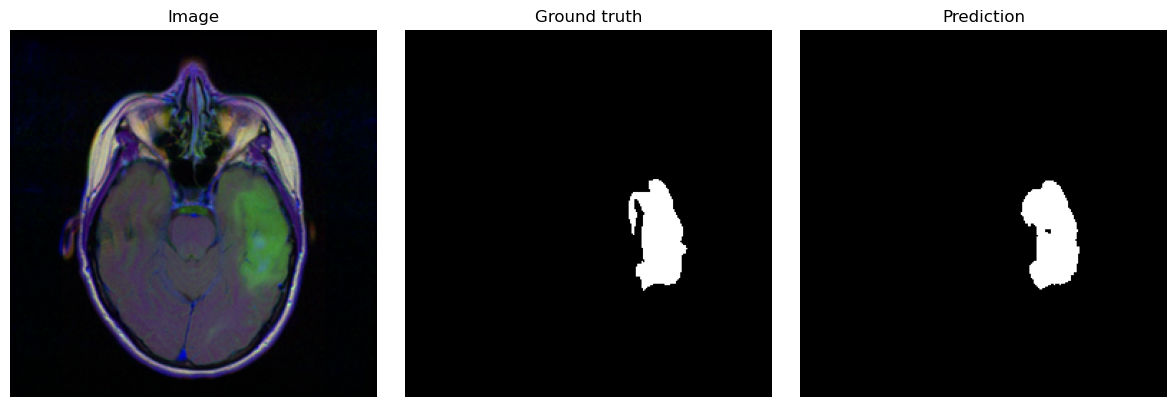

Final Val Dice: 0.7149
Final Val IoU : 0.6142


In [10]:
model = BaselineUNet()
device = torch.device('cuda')
model.to(device)
trained_model_tversky, results_tversky = train_bce_dice_loss(tversky_loss, model, train_loader, val_loader, device)
evaluate(results_tversky)

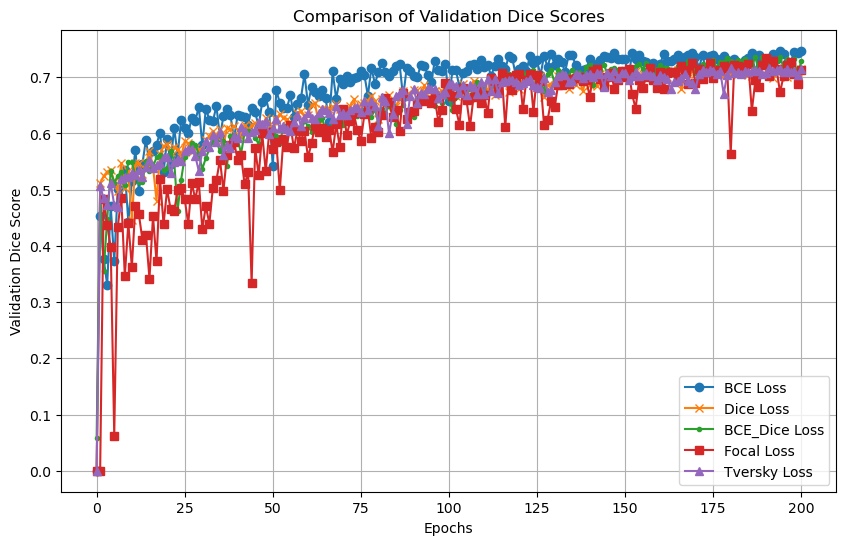

In [11]:
import matplotlib.pyplot as plt
def plot_val_dice_scores(results_bce, results_dice, results_bce_dice, results_focal, results_tversky):
    epochs = range(len(results_bce['history']['val_dice']))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, results_bce['history']['val_dice'], label='BCE Loss', marker='o')
    plt.plot(epochs, results_dice['history']['val_dice'], label='Dice Loss', marker='x')
    plt.plot(epochs, results_bce_dice['history']['val_dice'], label='BCE_Dice Loss', marker='.')
    plt.plot(epochs, results_focal['history']['val_dice'], label='Focal Loss', marker='s')
    plt.plot(epochs, results_tversky['history']['val_dice'], label='Tversky Loss', marker='^')

    plt.xlabel('Epochs')
    plt.ylabel('Validation Dice Score')
    plt.title('Comparison of Validation Dice Scores')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_val_dice_scores(results_bce, results_dice, results_bce_dice, results_focal, results_tversky)